# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Rafi Maulana Dzaky Bakhtiar
- **Email:** rafibakhtiar@student.ub.ac.id
- **ID Dicoding:** rafimbakhtiar

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana perbandingan jumlah penyewaan antara pengguna Casual (langganan harian) dan pengguna Registered (member) sepanjang tahun 2011-2012?
- Pertanyaan 2: Di musim (season) mana jumlah penyewaan mencapai titik tertinggi di setiap tahunnya?

## Import Semua Packages/Library yang Digunakan

In [40]:
#Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

## Data Wrangling

### Gathering Data

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
bike_day = pd.read_csv("/content/drive/MyDrive/FUNDAT DICODING/day.csv")
bike_day
bike_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Data bike_day memiliki 15 kolom yang mencatat aktivitas penyewaan sepeda dalam skala harian. Berbeda dengan data bike_hour, data ini memberikan gambaran per hari yang berguna untuk melihat tren jangka panjang.
- Kolom data bike_day adalah sebagai berikut instant, dteday, season, yr, mnth, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, casual, registered, dan cnt.
- Kolom cnt merupakan variabel target yang menunjukkan total penyewaan. Kolom cnt merupakan hasil penjumlahan dari casual (pengguna tidak terdaftar) dan registered (pengguna terdaftar).
- Kolom dteday berfungsi sebagai indeks waktu (tanggal).
- Kolom yr, mnth, holiday, weekday, dan workingday merupakan data kategorikal yang akan sangat berpengaruh dalam menentukan pola musiman.

### Assessing Data

In [43]:
bike_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [44]:
bike_day.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [45]:
#print('Jumlah duplikasi: ',bike_hour.duplicated().sum())
print("Jumlah duplikasi: ", bike_day.duplicated().sum())

Jumlah duplikasi:  0


In [46]:
bike_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Berdasarkan pengecekan bike_day.isna().sum() dan bike_day.duplicated().sum(), dataset bike_day bersih dari missing values dan tidak memiliki data duplikat. Seluruh baris yaitu sebanyak 731 baris data terisi penuh yang menunjukkan kualitas data sangat baik dan siap untuk tahap analisis selanjutnya tanpa perlu proses pembersihan yang serius.
- Kolom dteday terdeteksi sebagai tipe data object. Dataset ini adalah data time-series atau data deret waktu, tipe data perlu diubah menjadi datetime supaya operasi pemilihan berdasarkan tanggal, bulan, atau tahun bisa dilakukan dengan lebih optimal.
- Dataset menggunakan representasi numerik (int64) untuk variabel kategorikal seperti season, yr, mnth, holiday, weekday, workingday, dan weathersit. Untuk keperluan visualisasi, akan dilakukan mapping ke tipe data category agar label ('Springer', 'Clear', dst) muncul dengan jelas.
- Variabel cuaca seperti temp, atemp, hum, dan windspeed sudah berada dalam skala ternormalisasi dengan rentang 0 hingga 1.
- Rata-rata penyewaan sepeda per hari adalah sekitar 4.504 unit, dengan angka tertinggi mencapai 8.714 unit dalam satu hari.
- Standar deviasi yang mencapai 1.937 menunjukkan adanya fluktuasi yang cukup besar antar hari, yang kemungkinan kuat dipengaruhi oleh faktor musim atau hari libur.

### Cleaning Data

In [47]:
print(bike_day ["season"].value_counts())

season
3    188
2    184
1    181
4    178
Name: count, dtype: int64


In [48]:
label_season = {1: "Springer", 2: "Summer", 3: "Fall", 4: "Winter"}
bike_day ["season"] = bike_day ["season"].map(label_season)

In [49]:
print(bike_day ["yr"]. value_counts())

yr
1    366
0    365
Name: count, dtype: int64


In [50]:
label_year = {0: "2011", 1: "2012"}
bike_day ["yr"] = bike_day ["yr"].map(label_year)

In [51]:
print(bike_day ["mnth"].value_counts())

mnth
1     62
3     62
7     62
5     62
12    62
10    62
8     62
4     60
9     60
6     60
11    60
2     57
Name: count, dtype: int64


In [52]:
label_month = {
    1: "Januari",
    2: "Februari",
    3: "Maret",
    4: "April",
    5: "Mei",
    6: "Juni",
    7: "Juli",
    8: "Agustus",
    9: "September",
    10: "Oktober",
    11: "November",
    12: "Desember"
}
bike_day ["mnth"] = bike_day ["mnth"].map(label_month)

In [53]:
print(bike_day ["weekday"].value_counts())

weekday
6    105
0    105
1    105
2    104
3    104
4    104
5    104
Name: count, dtype: int64


In [54]:
label_weekday = {
    0: "Minggu",
    1: "Senin",
    2: "Selasa",
    3: "Rabu",
    4: "Kamis",
    5: "Jumat",
    6: "Sabtu"
}
bike_day ["weekday"] = bike_day ["weekday"].map(label_weekday)

In [55]:
print(bike_day ["workingday"].value_counts())

workingday
1    500
0    231
Name: count, dtype: int64


In [56]:
label_workingday = {
    0: "Weekend/Holiday",
    1: "Weekday"
}
bike_day ["workingday"] = bike_day ["workingday"].map(label_workingday)

In [57]:
print(bike_day ["weathersit"].value_counts())

weathersit
1    463
2    247
3     21
Name: count, dtype: int64


In [58]:
label_weathersit = {
    1: "Clear",
    2: "Mist or Cloudy",
    3: "Light Rain",
    4: "Heavy Rain"
}
bike_day ["weathersit"] = bike_day ["weathersit"].map(label_weathersit)

In [59]:
#Mengganti tipe kolom "dteday"
bike_day ["dteday"] = pd.to_datetime(bike_day ["dteday"])

#Cek
print("Info Dataframe setelah diubah tipe data:\n")
bike_day.info()

Info Dataframe setelah diubah tipe data:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    object        
 4   mnth        731 non-null    object        
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    object        
 7   workingday  731 non-null    object        
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int6

In [60]:
month_order = [
    "Januari", "Februari", "Maret",
    "April", "Mei", "Juni",
    "Juli", "Agustus", "September",
    "Oktober", "November", "Desember"
]
bike_day ["mnth"] = pd.Categorical(bike_day ["mnth"], categories= month_order, ordered=True)

In [61]:
bike_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Springer,2011,Januari,0,Sabtu,Weekend/Holiday,Mist or Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Springer,2011,Januari,0,Minggu,Weekend/Holiday,Mist or Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Springer,2011,Januari,0,Senin,Weekday,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Springer,2011,Januari,0,Selasa,Weekday,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Springer,2011,Januari,0,Rabu,Weekday,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Kolom dteday telah berhasil diubah dari tipe object menjadi datetime64[ns]. Memungkinkan untuk melakukan analisis tren (time-series analysis).
- Variabel numerik yang sebelumnya sulit dipahami secara langsung karena belum dikategorikan (season, yr, mnth, weekday, workingday, dan weathersit) sekarang sudah diubah menjadi label teks deskriptif.
- Menggunakan pd.Categorical pada kolom mnth (Januari-Desember), untuk memastikan bahwa saat data divisualisasikan urutan bulan tidak akan berantakan secara alfabetis, melainkan tetap mengikuti urutan kalender yang logis.
- Berdasarkan pengecekan value_counts(), sebaran data antar kategori terlihat seimbang. Contoh, jumlah data untuk tahun 2011 (365 hari) dan 2012 (366 hari — tahun kabisat) sudah sesuai dengan jumlah hari di dunia nyata, yang menandakan tidak ada data harian yang hilang selama periode tersebut.
- Setelah proses pembersihan, dataframe bike_day siap dianalisis. Data sudah memiliki konteks yang jelas pada tiap kolom.

## Exploratory Data Analysis (EDA)

### Explore ...

In [62]:
bike_day.describe(include = 'all')

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731,731,731,731.000000,731,731,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4,2,12,NaN,7,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,2012,Januari,NaN,Sabtu,Weekday,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188,366,62,NaN,105,500,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,0.028728,NaN,NaN,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [63]:
#Mengelompokkan data berdasarkan tahun dan menjumlahkan tipe pengguna
user_type_rentals = bike_day.groupby('yr')[['casual', 'registered']].sum().reset_index()
user_type_rentals

,yr,casual,registered
0,2011,247252,995851
1,2012,372765,1676811


In [64]:
#Mengelompokkan jumlah penyewaan tiap musim di setiap tahun
season_rentals = bike_day.groupby(['yr', 'season'])['cnt'].sum().reset_index()
season_rentals

,yr,season,cnt
0,2011,Fall,419650
1,2011,Springer,150000
2,2011,Summer,347316
3,2011,Winter,326137
4,2012,Fall,641479
5,2012,Springer,321348
6,2012,Summer,571273
7,2012,Winter,515476


In [65]:
#Mengetahui banyaknya sewa sepeda tiap musim pada tahun 2011 dan 2012
bike_day.groupby(by = ['yr','season']).agg({
    'cnt': 'sum'
})

cnt
yr   season          
2011 Fall      419650
     Springer  150000
     Summer    347316
     Winter    326137
2012 Fall      641479
     Springer  321348
     Summer    571273
     Winter    515476

In [66]:
#Mengetahui rata-rata sewa sepeda tiap musim pada tahun 2011 dan 2012
bike_day.groupby(by = ['yr','season']).agg({
    'cnt': 'mean'
})

cnt
yr   season               
2011 Fall      4464.361702
     Springer  1666.666667
     Summer    3775.173913
     Winter    3664.460674
2012 Fall      6824.244681
     Springer  3531.296703
     Summer    6209.489130
     Winter    5791.865169

In [67]:
#Mengetahui banyaknya sepeda yang tersewa tiap bulan pada tahun 2011 dan 2012
bike_day.groupby(by = ['yr', 'mnth']).agg({
    'cnt': 'sum'
})

/tmp/ipykernel_4664/3951477518.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bike_day.groupby(by = ['yr', 'mnth']).agg({


cnt
yr   mnth             
2011 Januari     38189
     Februari    48215
     Maret       64045
     April       94870
     Mei        135821
     Juni       143512
     Juli       141341
     Agustus    136691
     September  127418
     Oktober    123511
     November   102167
     Desember    87323
2012 Januari     96744
     Februari   103137
     Maret      164875
     April      174224
     Mei        195865
     Juni       202830
     Juli       203607
     Agustus    214503
     September  218573
     Oktober    198841
     November   152664
     Desember   123713

In [68]:
#Mengetahui persewaan sepeda saat cuaca tertentu
bike_day.groupby(by = ['yr', 'weathersit']).agg({
    'cnt': 'sum'
})

cnt
yr   weathersit             
2011 Clear            835067
     Light Rain        25112
     Mist or Cloudy   382924
2012 Clear           1422885
     Light Rain        12757
     Mist or Cloudy   613934

In [69]:
#Mengetahui rata- rata persewaan sepeda saat cuaca tertentu
bike_day.groupby(by = ['yr', 'weathersit']).agg({
    'cnt': 'mean'
})

cnt
yr   weathersit                 
2011 Clear           3694.986726
     Light Rain      1674.133333
     Mist or Cloudy  3088.096774
2012 Clear           6003.734177
     Light Rain      2126.166667
     Mist or Cloudy  4991.333333

In [70]:
#Mengetahui rata-rata sepeda yang tersewa pada tiap-tiap hari
bike_day.groupby(by = 'weekday').agg({
    'cnt': 'mean'
})

,cnt
weekday,
Jumat,4690.288462
Kamis,4667.259615
Minggu,4228.828571
Rabu,4548.538462
Sabtu,4550.542857
Selasa,4510.663462
Senin,4338.123810


In [71]:
#Mengetahui total sepeda yang tersewa pada tiap-tiap hari
bike_day.groupby(by = 'weekday').agg({
    'cnt': 'sum'
})

,cnt
weekday,
Jumat,487790
Kamis,485395
Minggu,444027
Rabu,473048
Sabtu,477807
Selasa,469109
Senin,455503


In [72]:
#Mengetahui banyaknya sepeda yang tersewa pada weekday dan weekend/holiday
bike_day.groupby(by = 'workingday').agg({
    'cnt': 'sum'
})

,cnt
workingday,
Weekday,2292410
Weekend/Holiday,1000269


**Insight:**
1.  **Pengguna terdaftar:**
*   Berdasarkan analisis perbandingan tipe pengguna, terdapat perbedaan volume yang sangat signifikan antara pengguna Casual dan Registered pada tahun 2011-2012.
*   Stabilitas Bisnis: Pengguna terdaftar (Registered) memberikan kontribusi utama (sekitar 80% dari total penyewaan). Hal ini mengindikasikan bahwa layanan ini memiliki basis pelanggan setia yang kuat dan telah menjadi bagian dari rutinitas harian.
*   Potensi Pertumbuhan: Meskipun volume pengguna Casual lebih kecil, pertumbuhannya dari tahun 2011 ke 2012 tetap positif, menunjukkan terdapat daya tarik layanan bagi pengguna baru atau wisatawan.
2.  **Analisis Musiman dan Tahunan:**
*   Peak Season (Musim Gugur/Fall): Musim Gugur menjadi periode keemasan dengan jumlah penyewaan tertinggi di tahun 2011 dan 2012. Hal ini kemungkinan dipengaruhi oleh suhu udara yang nyaman untuk aktivitas luar ruangan.
*   Low Season (Musim Semi/Springer): Terjadi penurunan signifikan pada musim semi. Bisa diambil keputusan bahwa meskipun suhu mulai menghangat, faktor lain seperti curah hujan atau transisi cuaca mungkin menghambat minat pengguna.
*   Pertumbuhan Agresif: Terjadi lonjakan total penyewaan yang sangat signifikan di semua musim pada tahun 2012 dibandingkan 2011, menandakan ekspansi bisnis atau peningkatan kesadaran masyarakat akan transportasi hijau.
3.  **Pengaruh Cuaca terhadap Aktivitas Pengguna:**
*   Kondisi Cerah (Clear): Menjadi pendorong utama penyewaan dengan angka rata-rata harian yang paling tinggi.
*   Cuaca Buruk: Terjadi penurunan drastis pada kondisi hujan ringan (Light Rain). Hal ini menunjukkan bahwa operasional sangat bergantung pada faktor eksternal (cuaca), sehingga diperlukan strategi mitigasi seperti promosi khusus atau peningkatan fasilitas pelindung di stasiun sepeda saat cuaca kurang mendukung.
4.  **Hari Kerja vs Hari Libur:**
*   Produktivitas di Hari Kerja: Total penyewaan pada hari kerja jauh melampaui hari libur. Memperkuat hipotesis bahwa sepeda digunakan sebagai transportasi utama untuk mobilitas produktif.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbandingan jumlah penyewaan antara pengguna Casual (langganan harian) dan pengguna Registered (member) sepanjang tahun 2011-2012?

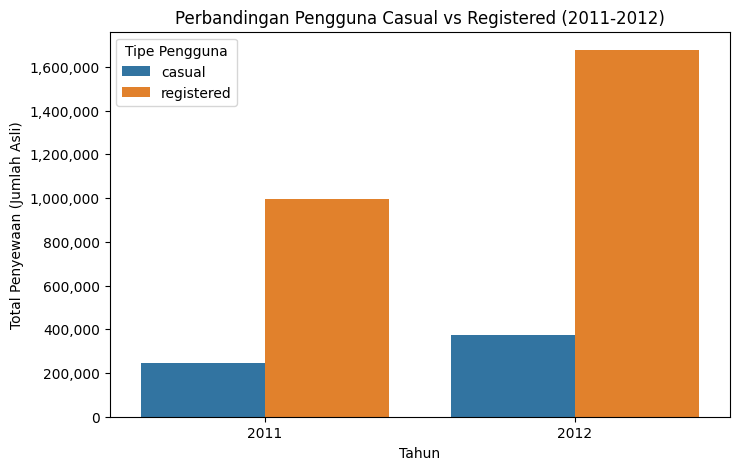

In [73]:
#Mengelompokkan data berdasarkan tahun dan menjumlahkan tipe pengguna
user_type_melted = user_type_rentals.melt(id_vars='yr', var_name='user_type', value_name='total_rentals')

#Visualisasi
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=user_type_melted, x='yr', y='total_rentals', hue='user_type')

#Fungsi untuk mengubah angka jutaan menjadi format yang mudah dibaca
def format_jutaan(x, pos):
    return f'{int(x):,}' # Menambahkan pemisah ribuan (koma atau titik)

ax.yaxis.set_major_formatter(FuncFormatter(format_jutaan))

plt.title('Perbandingan Pengguna Casual vs Registered (2011-2012)')
plt.xticks([0, 1], ['2011', '2012'])
plt.xlabel('Tahun')
plt.ylabel('Total Penyewaan (Jumlah Asli)')
plt.legend(title='Tipe Pengguna')

plt.show()

### Pertanyaan 2: Di musim (season) mana jumlah penyewaan mencapai titik tertinggi di setiap tahunnya?

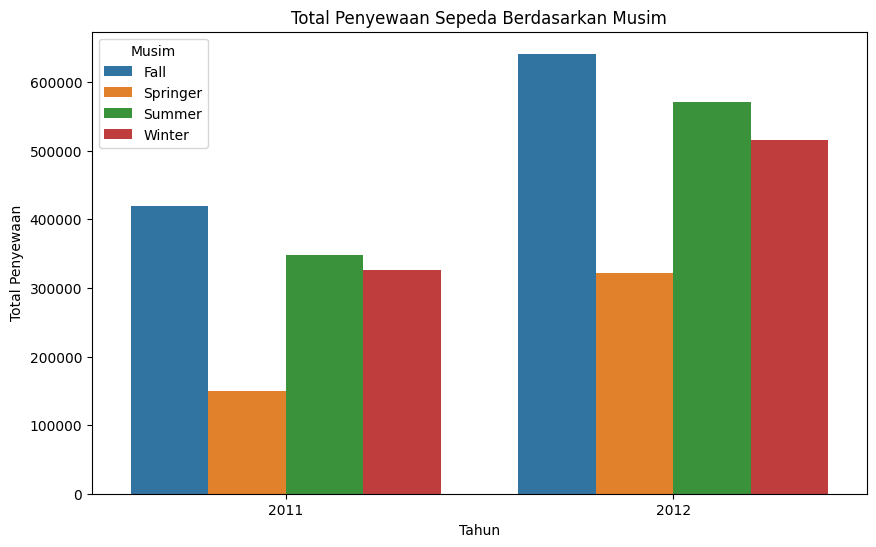

In [74]:
#Mengelompokkan
season_rentals = bike_day.groupby(['yr', 'season'])['cnt'].sum().reset_index()

#Visualisasi dengan penegasan sumbu X dan Y
plt.figure(figsize=(10, 6))
sns.barplot(data=season_rentals, x='yr', y='cnt', hue='season')

#Menambahkan label manual untuk memastikan sumbu X benar
plt.xticks([0, 1], ['2011', '2012'])

plt.title('Total Penyewaan Sepeda Berdasarkan Musim')
plt.xlabel('Tahun')
plt.ylabel('Total Penyewaan')
plt.legend(title='Musim')
plt.show()

**Insight:**
1.  **Perbandingan Pengguna Casual dengan Registered**
*   Dominansi Jumlah Pelanggan: Pengguna Registered (member) mendominasi total penyewaan secara nyata di kedua tahun. Pada tahun 2012, jumlah pengguna Registered menembus angka di atas 1.600.000, jauh melampaui pengguna Casual yang berada di kisaran 400.000.
*   Loyalitas dan Stabilitas: Perbandingan menunjukkan bahwa bisnis penyewaan sepeda memiliki tingkat retensi yang tinggi. Layanan ini bukan sekadar tren sesaat bagi turis (Casual), melainkan sudah menjadi alat transportasi rutin bagi penduduk lokal atau pekerja (Registered) untuk mobilitas sehari-hari.
*   Pertumbuhan Signifikan: Kedua kategori menunjukkan tren positif. Pengguna Registered mengalami lonjakan pertumbuhan yang lebih tajam di tahun 2012, yang mengindikasikan keberhasilan program keanggotaan.
2.  **Tren Penyewaan Berdasarkan Musim**
*   Puncak Penyewaan (Peak Season): Di kedua tahun (2011 dan 2012), Musim Gugur (Fall) secara konsisten menjadi musim dengan jumlah penyewaan tertinggi. Pada tahun 2012, penyewaan sepeda di musim gugur mencapai puncaknya di angka lebih dari 600.000 kali sewa.
*   Analisis Musiman: Musim Panas (Summer) menempati posisi kedua, disusul oleh Musim Dingin (Winter). Hal ini membuktikan bahwa cuaca dan suhu udara yang moderat (tidak terlalu panas dan tidak terlalu dingin) adalah faktor pendorong utama minat masyarakat dalam bersepeda.
*   Titik Terendah: Musim Semi (Springer) memiliki angka penyewaan terendah. Sebagai catatan evaluasi, perusahaan perlu menyelidiki apakah ada faktor eksternal di musim semi (seperti curah hujan tinggi atau suhu yang masih terlalu transisi) yang menghambat keinginan pengguna, sehingga strategi promosi tambahan mungkin diperlukan di periode ini.

## Analisis Lanjutan (Opsional)

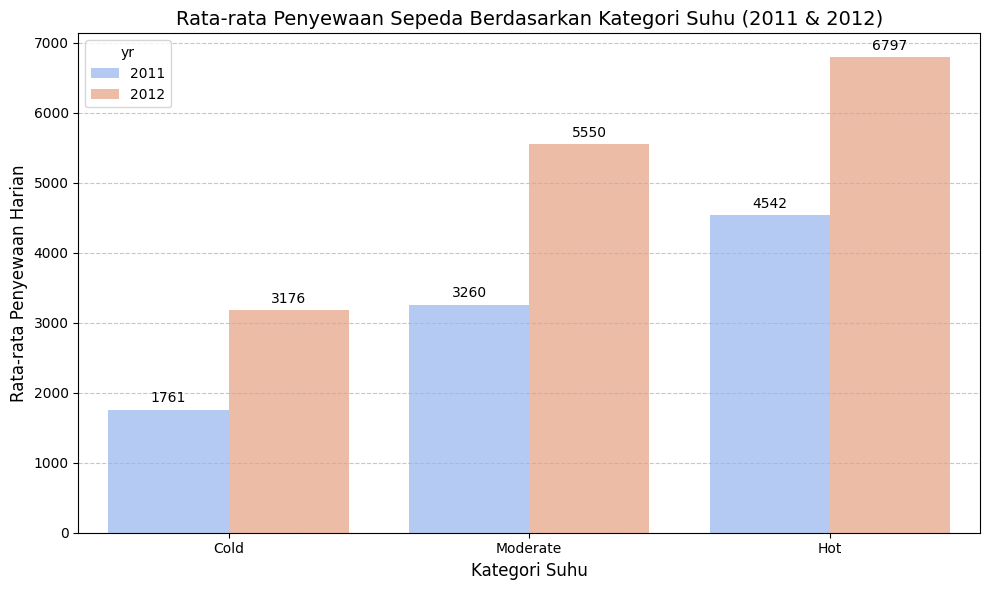

In [75]:
# 1. Membuat Fungsi untuk Binning Suhu (Manual Grouping)
# Karena 'temp' di dataset ini sudah dinormalisasi (0 sampai 1), kita bagi jadi 3 kategori
def group_temp(temp):
    if temp < 0.3:
        return 'Cold'
    elif 0.3 <= temp < 0.6:
        return 'Moderate'
    else:
        return 'Hot'

# 2. Menerapkan fungsi ke kolom baru
bike_day['temp_category'] = bike_day['temp'].apply(group_temp)

# 3. Mengurutkan kategori agar rapi di grafik
temp_order = ['Cold', 'Moderate', 'Hot']
bike_day['temp_category'] = pd.Categorical(bike_day['temp_category'], categories=temp_order, ordered=True)

# 4. Grouping data untuk visualisasi
temp_rentals = bike_day.groupby(by=['yr', 'temp_category'], observed=False).agg({
    'cnt': 'mean' # Menggunakan Mean (rata-rata) lebih akurat untuk perbandingan kategori
}).reset_index()

# 5. Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(data=temp_rentals, x='temp_category', y='cnt', hue='yr', palette='coolwarm')

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kategori Suhu (2011 & 2012)', fontsize=14)
plt.xlabel('Kategori Suhu', fontsize=12)
plt.ylabel('Rata-rata Penyewaan Harian', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menambahkan label angka di atas batang
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

## Insight dari rata-rata penyewaan sepeda berdasarkan kategori suhu

*   **Preferensi Suhu Hangat (Hot):** Data menunjukkan terdapat tren linear positif antara suhu dan jumlah penyewaan. Kategori 'Hot' mencatat rata-rata penyewaan tertinggi di kedua tahun, puncaknya pada rata-rata 6.797 sewa per hari di tahun 2012. Hal ini mengindikasikan bahwa pengguna jauh lebih antusias menggunakan sepeda saat cuaca cenderung hangat, yang biasanya berkaitan dengan kondisi langit cerah.
*   **Dampak Signifikan Suhu Rendah (Cold):** Terjadi penurunan performa yang cukup drastis pada kategori 'Cold'. Rata-rata harian pada suhu dingin di tahun 2011 hanya sebesar 1.761 penyewa, tidak sampai setengah dari rata-rata pada suhu panas di tahun yang sama. Hal ini menunjukkan bahwa suhu ekstrem dingin merupakan faktor penghambat bagi pengguna dalam memanfaatkan layanan berbagi sepeda.
*   Kategori 'Moderate' menunjukkan angka yang stabil dan mengalami pertumbuhan pesat kurang lebih 70% dari tahun 2011 ke 2012. Pertumbuhan ini mencerminkan bahwa meskipun cuaca tidak dalam kondisi "paling ideal" (hangat), penerimaan masyarakat terhadap layanan ini terus meningkat secara substansial.
*   Bagi pengelola, data ini memberikan dasar strategis dalam manajemen aset. Pada musim dengan suhu dominan 'Cold', operator dapat menjadwalkan pemeliharaan karena permintaan sedang rendah. Sebaliknya, pada kategori 'Moderate' dan 'Hot', ketersediaan sepeda di setiap stasiun harus dipastikan berada pada level maksimal untuk menangkap tingginya permintaan pasar.

## Conclusion

- Conclution pertanyaan 1: Berdasarkan hasil analisis, pengguna Registered (member) merupakan kontributor utama dalam ekosistem penyewaan sepeda dengan volume yang lebih besar daripada pengguna Casual. Hal ini menunjukkan bahwa layanan ini telah berhasil membangun basis loyalitas yang kuat dan menjadi alat transportasi rutin bagi penduduk lokal.
  - Program Loyalitas/Member: Pertahankan dominansi pengguna Registered melalui program reward atau skema berlangganan jangka panjang yang lebih kompetitif untuk meningkatkan loyalitas.
  - Konversi Pengguna Casual: Kembangkan strategi pemasaran untuk mengonversi pengguna Casual menjadi Registered, terutama pada periode liburan atau akhir pekan di mana volume pengguna Casual cenderung meningkat, seperti paket 24 jam hingga mingguan.
- Conclution pertanyaan 2: Analisis musiman mengonfirmasi bahwa Musim Gugur (Fall) dan Musim Panas (Summer) secara konsisten mencatatkan aktivitas penyewaan tertinggi. Faktor kenyamanan menjadi penentu utama perilaku pengguna, sementara Musim Semi (Springer) menjadi periode dengan aktivitas terendah yang memerlukan perhatian khusus.
  - Optimalisasi Inventaris: Memastikan ketersediaan armada berada pada kapasitas maksimal selama musim puncak (Fall & Summer) untuk menangkap peluang permintaan yang tinggi.
  - Strategi Musim Rendah: Lakukan evaluasi mendalam pada Musim Semi dengan mempertimbangkan promosi khusus atau paket diskon "awal musim" untuk merangsang minat pengguna di tengah kondisi cuaca transisi.
- Conclution analisis lanjutan: Melalui teknik manual grouping, ditemukan korelasi linear positif yang signifikan antara suhu udara dan produktivitas layanan. Kategori suhu 'Hot' dan 'Moderate' mendorong penggunaan sepeda secara masif, sedangkan kategori 'Cold' menjadi faktor penghambat operasional yang menurunkan volume penyewaan harian secara drastis.
  - Manajemen Aset Dinamis: Menggunakan data suhu harian untuk mengatur jadwal pemeliharaan rutin pada saat kategori suhu 'Cold', untuk meminimalisir gangguan layanan saat periode sibuk.
  - Penyediaan Fasilitas Pendukung: Pertimbangkan penyediaan fasilitas tambahan atau edukasi keselamatan bersepeda pada suhu tinggi guna menjaga kenyamanan pengguna pada kategori suhu 'Hot'.

In [76]:
bike_day.to_csv('bike_day.csv', index=False)

In [77]:
bike_day

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,temp_category
0,1,2011-01-01,Springer,2011,Januari,0,Sabtu,Weekend/Holiday,Mist or Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985,Moderate
1,2,2011-01-02,Springer,2011,Januari,0,Minggu,Weekend/Holiday,Mist or Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801,Moderate
2,3,2011-01-03,Springer,2011,Januari,0,Senin,Weekday,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Cold
3,4,2011-01-04,Springer,2011,Januari,0,Selasa,Weekday,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562,Cold
4,5,2011-01-05,Springer,2011,Januari,0,Rabu,Weekday,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600,Cold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,Springer,2012,Desember,0,Kamis,Weekday,Mist or Cloudy,0.254167,0.226642,0.652917,0.350133,247,1867,2114,Cold
727,728,2012-12-28,Springer,2012,Desember,0,Jumat,Weekday,Mist or Cloudy,0.253333,0.255046,0.590000,0.155471,644,2451,3095,Cold
728,729,2012-12-29,Springer,2012,Desember,0,Sabtu,Weekend/Holiday,Mist or Cloudy,0.253333,0.242400,0.752917,0.124383,159,1182,1341,Cold
729,730,2012-12-30,Springer,2012,Desember,0,Minggu,Weekend/Holiday,Clear,0.255833,0.231700,0.483333,0.350754,364,1432,1796,Cold
